# Addis Ababa: Diurnal Multi-Wavelength Analysis

**Motivation**: Sean Raffuse shared ASCENT data from Queens College, NY showing dramatic
sub-daily airmass shifts hidden in 24-hr averages. Ann Dillner noted that the aethalometer
wavelengths are quite different from 1-5 AM but very similar from 5-9 AM in that data.

**Key question**: Does the Addis Ababa aethalometer show similar wavelength
divergence/convergence patterns throughout the day? Or are the wavelengths "the same all
the time"?

**Why this matters**: When wavelengths diverge (especially UV rising above IR), it signals
brown carbon / biomass burning contribution. When they converge, a single source type
(e.g. traffic/fossil fuel) dominates. The diurnal pattern of this divergence reveals how
source mixtures change throughout the day.

## Analyses
1. Multi-wavelength diurnal overlay (all 5 wavelengths)
2. Normalized wavelength ratios (spectral shape, removing concentration effects)
3. AAE diurnal pattern (source indicator)
4. Delta-C diurnal pattern (biomass burning marker)
5. Wavelength spread metric by hour
6. Seasonal breakdown of diurnal wavelength patterns
7. Representative individual days

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import os, sys
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 120,
})

# Output directory
PLOT_DIR = 'output/plots/addis_ababa/diurnal_wavelength'
os.makedirs(PLOT_DIR, exist_ok=True)

# Wavelength configuration (MA350 channels)
WAVELENGTHS = {
    'UV':    {'nm': 375, 'color': '#7B2FBE'},   # violet/purple
    'Blue':  {'nm': 470, 'color': '#2196F3'},
    'Green': {'nm': 528, 'color': '#4CAF50'},
    'Red':   {'nm': 625, 'color': '#F44336'},
    'IR':    {'nm': 880, 'color': '#212121'},
}

BC_COLS = {name: f'{name} BCc' for name in WAVELENGTHS}
BC_SMOOTH_COLS = {name: f'{name} BCc smoothed' for name in WAVELENGTHS}

# Ethiopian seasons
SEASONS = {
    'Dry (Oct-Feb)': [10, 11, 12, 1, 2],
    'Belg (Mar-May)': [3, 4, 5],
    'Kiremt (Jun-Sep)': [6, 7, 8, 9],
}
SEASON_COLORS = {
    'Dry (Oct-Feb)': '#E67E22',
    'Belg (Mar-May)': '#27AE60',
    'Kiremt (Jun-Sep)': '#3498DB',
}

def month_to_season(m):
    for season, months in SEASONS.items():
        if m in months:
            return season

print("Setup complete")

Setup complete


## Data Loading

Load the 1-minute resolution MA350 data from Addis Ababa. Convert from ng/m3 to ug/m3.
Apply basic QC: remove negatives and clip extreme outliers (>3 sigma).

In [2]:
# Load 1-minute resolution cleaned aethalometer data
DATA_PATH = (
    "/Users/ahmadjalil/Desktop/"
    "JacrosMA350 60s Data20250804082112/"
    "df_jacros_cleaned_API_and_OG_manual_BC_all_wl.pkl"
)

df_raw = pd.read_pickle(DATA_PATH)
df_raw['datetime_local'] = pd.to_datetime(df_raw['datetime_local'])
df_raw = df_raw.set_index('datetime_local').sort_index()

print(f"Loaded {len(df_raw):,} records  ({df_raw.index.min()} to {df_raw.index.max()})")

# --- QC and unit conversion ---
all_bc = list(BC_COLS.values()) + list(BC_SMOOTH_COLS.values())
existing_bc = [c for c in all_bc if c in df_raw.columns]

df = df_raw[existing_bc].copy()

# Convert ng/m3 -> ug/m3
df[existing_bc] = df[existing_bc] / 1000.0

# Remove negatives
for c in existing_bc:
    df.loc[df[c] < 0, c] = np.nan

# Clip extreme outliers per column (> mean + 3*std on clean data)
for c in existing_bc:
    valid = df[c].dropna()
    upper = valid.mean() + 3 * valid.std()
    df.loc[df[c] > upper, c] = np.nan

# Add time features
df['Hour'] = df.index.hour
df['Month'] = df.index.month
df['Date'] = df.index.date
df['Season'] = df['Month'].map(month_to_season)

print(f"After QC: {df[list(BC_COLS.values())].notna().all(axis=1).sum():,} rows with all 5 wavelengths valid")
print(f"\nSample statistics (ug/m3):")
df[list(BC_COLS.values())].describe().round(2)

Loaded 1,556,717 records  (2022-04-12 12:53:08+03:00 to 2025-06-27 02:17:37+03:00)


After QC: 1,169,229 rows with all 5 wavelengths valid

Sample statistics (ug/m3):


,UV BCc,Blue BCc,Green BCc,Red BCc,IR BCc
count,1211342.00,1521168.00,1522663.00,1520910.00,1520632.00
mean,36.39,6.91,3.66,6.78,6.81
std,270.90,5.88,3.39,5.79,5.85
min,0.00,0.00,0.00,0.00,0.00
25%,5.02,3.00,1.41,2.92,2.93
50%,9.34,5.06,2.52,4.96,4.97
75%,20.03,8.63,4.65,8.47,8.51
max,17682.15,32.41,19.24,31.92,32.25


---
## 1. Multi-Wavelength Diurnal Overlay

Plot all 5 BCc wavelengths by hour of day. This is the direct analog to the aethalometer
panel in Sean's Queens College plot. If wavelengths diverge at certain hours (UV pulls away
from IR), that indicates biomass/brown carbon contribution during those hours.

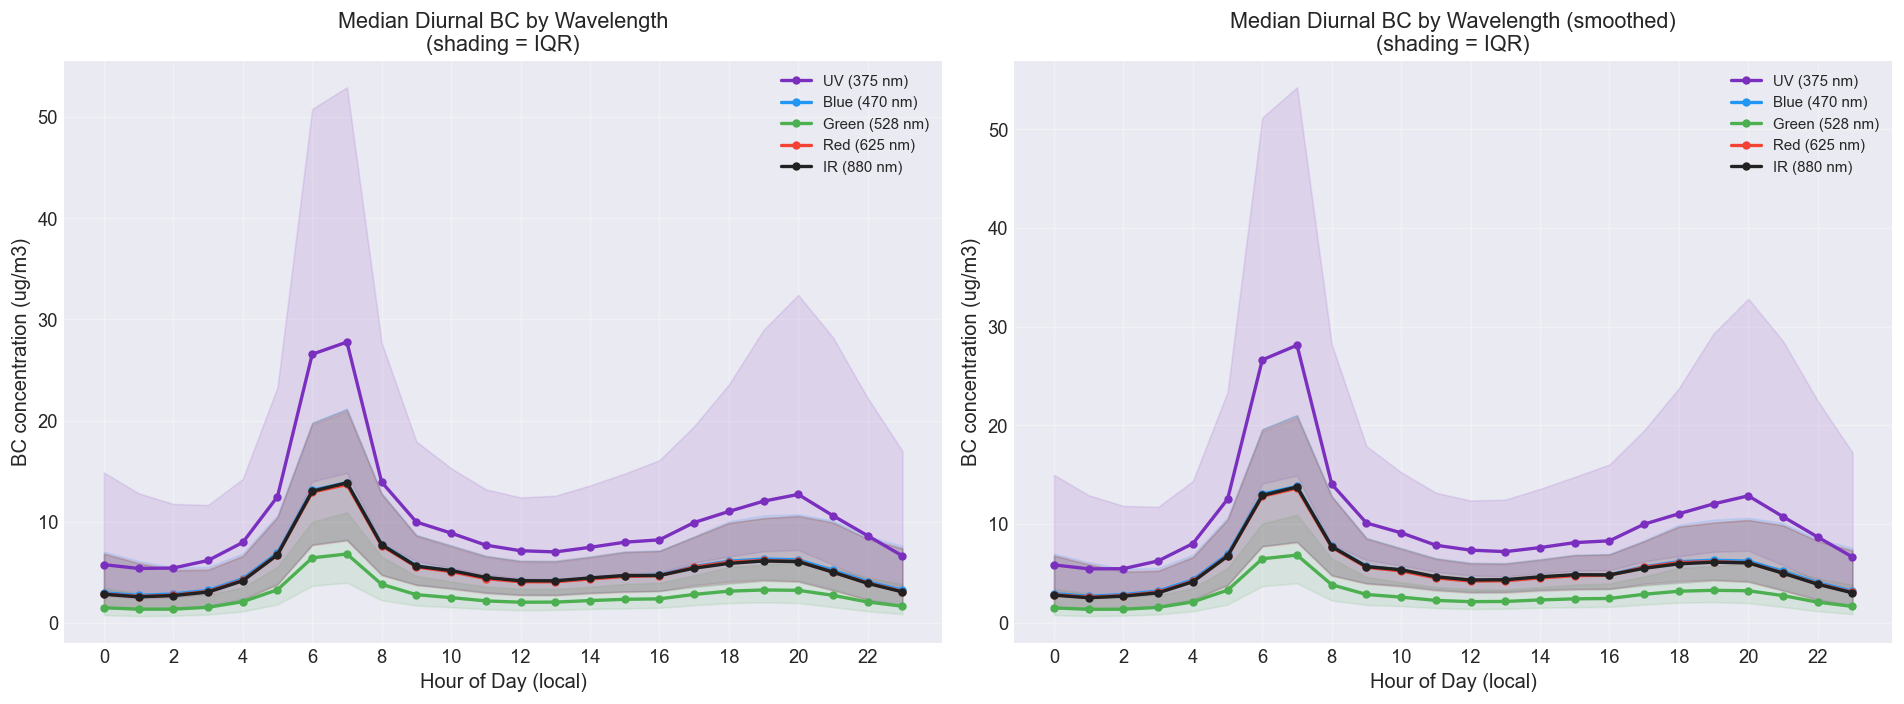


Key observation: look for hours where lines separate (wavelength-dependent absorption = mixed sources)
vs. hours where they collapse together (uniform absorption = single dominant source).


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Absolute concentrations ---
ax = axes[0]
for name, info in WAVELENGTHS.items():
    col = BC_COLS[name]
    hourly = df.groupby('Hour')[col]
    med = hourly.median()
    q25 = hourly.quantile(0.25)
    q75 = hourly.quantile(0.75)

    label = f"{name} ({info['nm']} nm)"
    ax.plot(med.index, med.values, marker='o', ms=4, lw=2,
            color=info['color'], label=label)
    ax.fill_between(med.index, q25, q75, alpha=0.12, color=info['color'])

ax.set_xlabel('Hour of Day (local)')
ax.set_ylabel('BC concentration (ug/m3)')
ax.set_title('Median Diurnal BC by Wavelength\n(shading = IQR)')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Right: Smoothed version (less noise) ---
ax = axes[1]
for name, info in WAVELENGTHS.items():
    col = BC_SMOOTH_COLS[name]
    if col not in df.columns:
        continue
    hourly = df.groupby('Hour')[col]
    med = hourly.median()
    q25 = hourly.quantile(0.25)
    q75 = hourly.quantile(0.75)

    ax.plot(med.index, med.values, marker='o', ms=4, lw=2,
            color=info['color'], label=f"{name} ({info['nm']} nm)")
    ax.fill_between(med.index, q25, q75, alpha=0.12, color=info['color'])

ax.set_xlabel('Hour of Day (local)')
ax.set_ylabel('BC concentration (ug/m3)')
ax.set_title('Median Diurnal BC by Wavelength (smoothed)\n(shading = IQR)')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/diurnal_all_wavelengths.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey observation: look for hours where lines separate (wavelength-dependent "
      "absorption = mixed sources)\nvs. hours where they collapse together "
      "(uniform absorption = single dominant source).")

---
## 2. Normalized Wavelength Ratios (Spectral Shape)

Dividing each wavelength by IR BCc removes the absolute concentration and isolates the
**spectral shape**. A flat line at 1.0 = all wavelengths equal (pure fossil fuel / soot).
UV/IR ratio > 1 = enhanced UV absorption = biomass burning / brown carbon contribution.

This is the most direct answer to Ann's question.

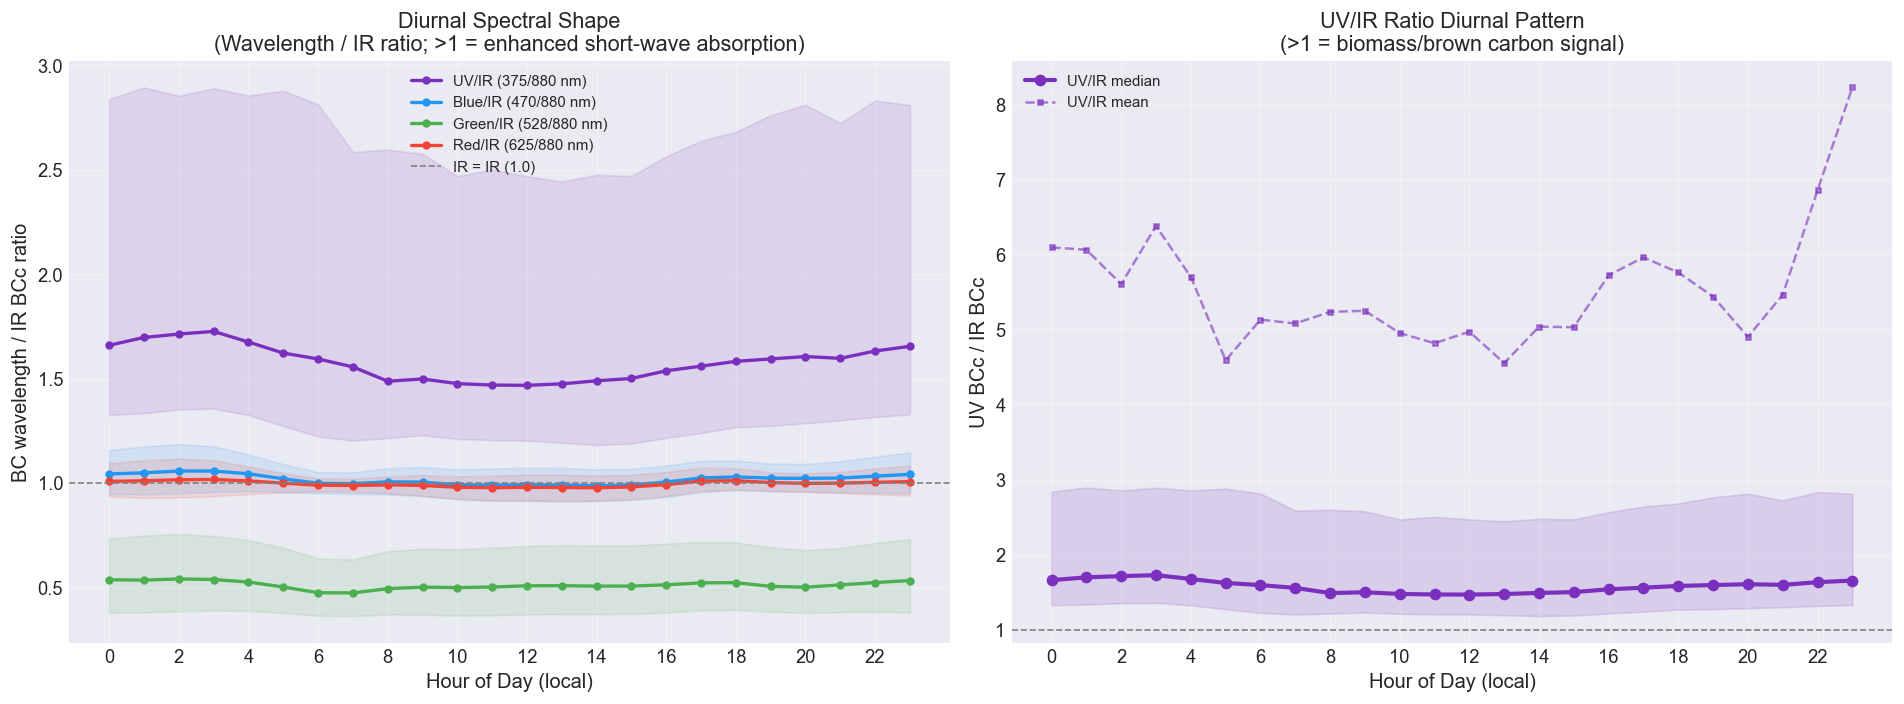

UV/IR ratio -- peak at 03:00 (1.73), minimum at 12:00 (1.47)
Diurnal range: 0.26


In [4]:
# Compute wavelength / IR ratios
ir_col = BC_COLS['IR']
ratio_cols = {}
for name in ['UV', 'Blue', 'Green', 'Red']:
    col = BC_COLS[name]
    rcol = f'{name}/IR ratio'
    # Only compute where both are valid and IR > 0
    mask = (df[col].notna()) & (df[ir_col].notna()) & (df[ir_col] > 0.1)
    df[rcol] = np.where(mask, df[col] / df[ir_col], np.nan)
    ratio_cols[name] = rcol

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Median ratio by hour ---
ax = axes[0]
for name in ['UV', 'Blue', 'Green', 'Red']:
    rcol = ratio_cols[name]
    med = df.groupby('Hour')[rcol].median()
    q25 = df.groupby('Hour')[rcol].quantile(0.25)
    q75 = df.groupby('Hour')[rcol].quantile(0.75)
    info = WAVELENGTHS[name]
    ax.plot(med.index, med.values, marker='o', ms=4, lw=2,
            color=info['color'], label=f"{name}/IR ({info['nm']}/{WAVELENGTHS['IR']['nm']} nm)")
    ax.fill_between(med.index, q25, q75, alpha=0.12, color=info['color'])

ax.axhline(1.0, color='gray', ls='--', lw=1, label='IR = IR (1.0)')
ax.set_xlabel('Hour of Day (local)')
ax.set_ylabel('BC wavelength / IR BCc ratio')
ax.set_title('Diurnal Spectral Shape\n(Wavelength / IR ratio; >1 = enhanced short-wave absorption)')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Right: Just UV/IR ratio with tighter view ---
ax = axes[1]
rcol = ratio_cols['UV']
hourly = df.groupby('Hour')[rcol]
med = hourly.median()
q25 = hourly.quantile(0.25)
q75 = hourly.quantile(0.75)
mean = hourly.mean()

ax.plot(med.index, med.values, 'o-', lw=2.5, color=WAVELENGTHS['UV']['color'],
        label='UV/IR median')
ax.plot(mean.index, mean.values, 's--', lw=1.5, ms=3, color=WAVELENGTHS['UV']['color'],
        alpha=0.6, label='UV/IR mean')
ax.fill_between(med.index, q25, q75, alpha=0.15, color=WAVELENGTHS['UV']['color'])
ax.axhline(1.0, color='gray', ls='--', lw=1)

ax.set_xlabel('Hour of Day (local)')
ax.set_ylabel('UV BCc / IR BCc')
ax.set_title('UV/IR Ratio Diurnal Pattern\n(>1 = biomass/brown carbon signal)')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/diurnal_wavelength_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
peak_hour = med.idxmax()
min_hour = med.idxmin()
print(f"UV/IR ratio -- peak at {peak_hour:02d}:00 ({med[peak_hour]:.2f}), "
      f"minimum at {min_hour:02d}:00 ({med[min_hour]:.2f})")
print(f"Diurnal range: {med.max() - med.min():.2f}")

---
## 3. Absorption Angstrom Exponent (AAE) Diurnal Pattern

AAE quantifies the wavelength dependence of absorption:
- **AAE ~ 1.0**: Pure fossil fuel / traffic BC (absorption scales as lambda^-1)
- **AAE ~ 1.5-2.0+**: Biomass burning / brown carbon (enhanced UV absorption)

Calculated from UV (375 nm) and IR (880 nm): `AAE = -ln(BC_UV / BC_IR) / ln(375 / 880)`

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_44830/1069397125.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(block_data, labels=block_labels, patch_artist=True, showfliers=False,


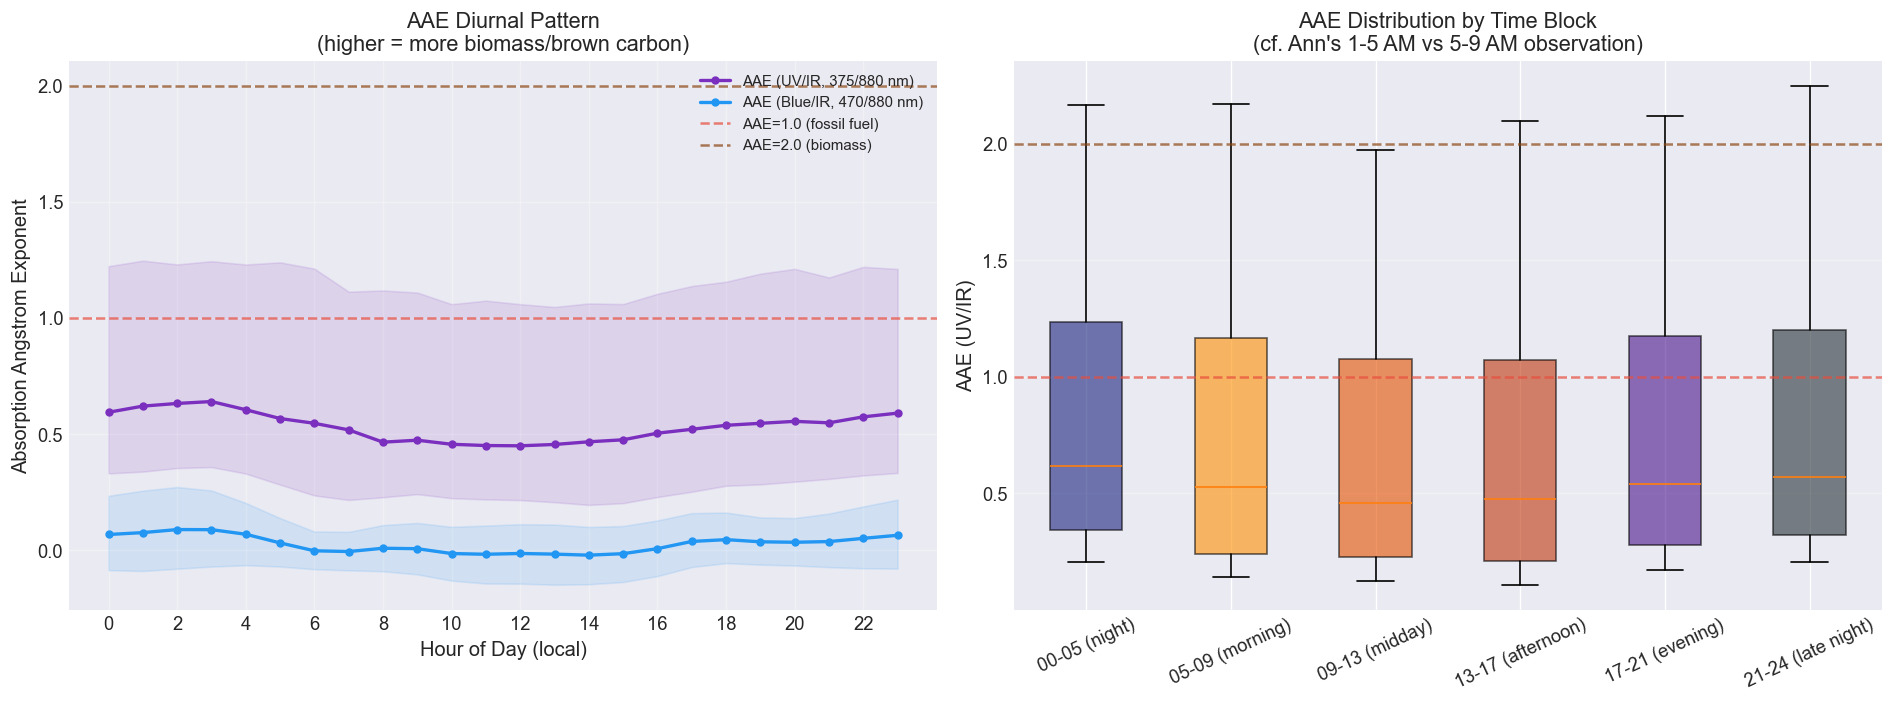

AAE (UV/IR) by time block (median):
  00-05 (night): 0.62
  05-09 (morning): 0.53
  09-13 (midday): 0.46
  13-17 (afternoon): 0.47
  17-21 (evening): 0.54
  21-24 (late night): 0.57


In [5]:
# Calculate AAE from UV and IR
uv_col, ir_col = BC_COLS['UV'], BC_COLS['IR']
wl_uv, wl_ir = WAVELENGTHS['UV']['nm'], WAVELENGTHS['IR']['nm']

mask = (df[uv_col] > 0.1) & (df[ir_col] > 0.1)
df['AAE_UV_IR'] = np.where(
    mask,
    -np.log(df[uv_col] / df[ir_col]) / np.log(wl_uv / wl_ir),
    np.nan
)

# Also compute Blue/IR AAE for comparison
blue_col = BC_COLS['Blue']
wl_blue = WAVELENGTHS['Blue']['nm']
mask2 = (df[blue_col] > 0.1) & (df[ir_col] > 0.1)
df['AAE_Blue_IR'] = np.where(
    mask2,
    -np.log(df[blue_col] / df[ir_col]) / np.log(wl_blue / wl_ir),
    np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: AAE diurnal ---
ax = axes[0]
for aae_col, color, label in [
    ('AAE_UV_IR', WAVELENGTHS['UV']['color'], 'AAE (UV/IR, 375/880 nm)'),
    ('AAE_Blue_IR', WAVELENGTHS['Blue']['color'], 'AAE (Blue/IR, 470/880 nm)'),
]:
    hourly = df.groupby('Hour')[aae_col]
    med = hourly.median()
    q25 = hourly.quantile(0.25)
    q75 = hourly.quantile(0.75)
    ax.plot(med.index, med.values, 'o-', lw=2, ms=4, color=color, label=label)
    ax.fill_between(med.index, q25, q75, alpha=0.12, color=color)

ax.axhline(1.0, color='#E74C3C', ls='--', lw=1.5, alpha=0.7, label='AAE=1.0 (fossil fuel)')
ax.axhline(2.0, color='#8B4513', ls='--', lw=1.5, alpha=0.7, label='AAE=2.0 (biomass)')
ax.set_xlabel('Hour of Day (local)')
ax.set_ylabel('Absorption Angstrom Exponent')
ax.set_title('AAE Diurnal Pattern\n(higher = more biomass/brown carbon)')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Right: AAE distribution by time block (like Ann's 1-5 AM vs 5-9 AM) ---
ax = axes[1]
time_blocks = {
    '00-05 (night)':   (0, 5),
    '05-09 (morning)': (5, 9),
    '09-13 (midday)':  (9, 13),
    '13-17 (afternoon)': (13, 17),
    '17-21 (evening)': (17, 21),
    '21-24 (late night)': (21, 24),
}

block_data = []
block_labels = []
block_colors = ['#1a237e', '#ff8f00', '#e65100', '#bf360c', '#4a148c', '#263238']
for (label, (h_start, h_end)), color in zip(time_blocks.items(), block_colors):
    mask = (df['Hour'] >= h_start) & (df['Hour'] < h_end)
    vals = df.loc[mask, 'AAE_UV_IR'].dropna()
    block_data.append(vals)
    block_labels.append(label)

bp = ax.boxplot(block_data, labels=block_labels, patch_artist=True, showfliers=False,
                whis=[10, 90])
for patch, color in zip(bp['boxes'], block_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(1.0, color='#E74C3C', ls='--', lw=1.5, alpha=0.7)
ax.axhline(2.0, color='#8B4513', ls='--', lw=1.5, alpha=0.7)
ax.set_ylabel('AAE (UV/IR)')
ax.set_title('AAE Distribution by Time Block\n(cf. Ann\'s 1-5 AM vs 5-9 AM observation)')
ax.tick_params(axis='x', rotation=25)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/diurnal_AAE.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("AAE (UV/IR) by time block (median):")
for (label, (h_start, h_end)) in time_blocks.items():
    mask = (df['Hour'] >= h_start) & (df['Hour'] < h_end)
    med = df.loc[mask, 'AAE_UV_IR'].median()
    print(f"  {label}: {med:.2f}")

---
## 4. Delta-C Diurnal Pattern

Delta-C = UV BCc - IR BCc is a simple biomass burning tracer.
Positive Delta-C indicates biomass/brown carbon contribution; near-zero means fossil fuel dominance.

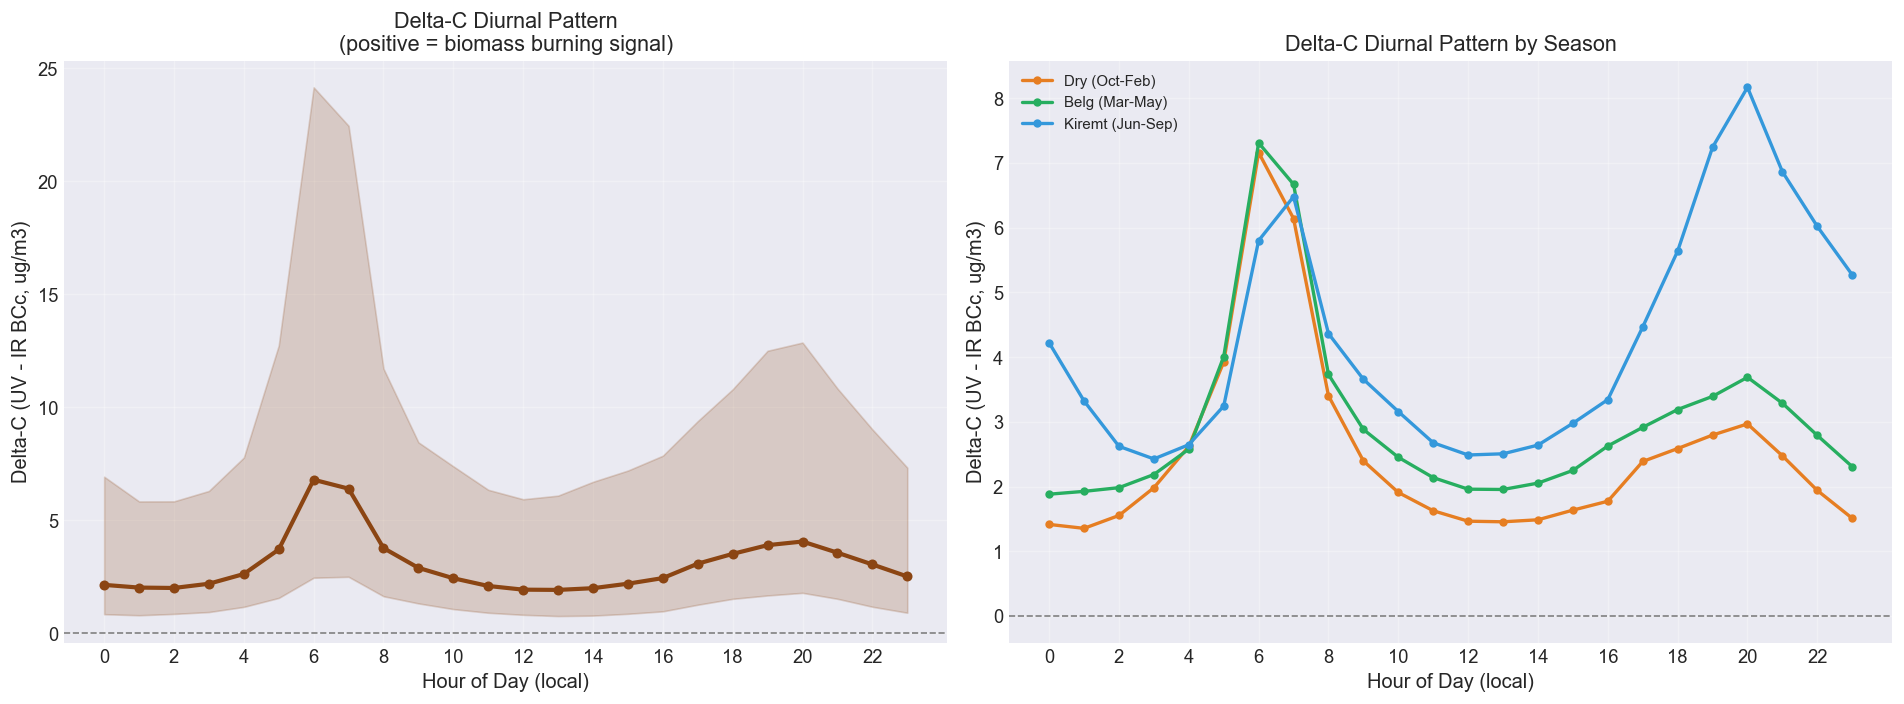

In [6]:
# Delta-C = UV BCc - IR BCc
df['Delta_C'] = df[BC_COLS['UV']] - df[BC_COLS['IR']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Delta-C diurnal ---
ax = axes[0]
hourly = df.groupby('Hour')['Delta_C']
med = hourly.median()
q25 = hourly.quantile(0.25)
q75 = hourly.quantile(0.75)

ax.plot(med.index, med.values, 'o-', lw=2.5, ms=5, color='#8B4513')
ax.fill_between(med.index, q25, q75, alpha=0.2, color='#8B4513')
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xlabel('Hour of Day (local)')
ax.set_ylabel('Delta-C (UV - IR BCc, ug/m3)')
ax.set_title('Delta-C Diurnal Pattern\n(positive = biomass burning signal)')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)

# --- Right: Delta-C by season ---
ax = axes[1]
for season, color in SEASON_COLORS.items():
    sdata = df[df['Season'] == season]
    hourly = sdata.groupby('Hour')['Delta_C']
    med = hourly.median()
    ax.plot(med.index, med.values, 'o-', lw=2, ms=4, color=color, label=season)

ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xlabel('Hour of Day (local)')
ax.set_ylabel('Delta-C (UV - IR BCc, ug/m3)')
ax.set_title('Delta-C Diurnal Pattern by Season')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/diurnal_deltaC.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Wavelength Spread Metric

Coefficient of variation (CV) across the 5 wavelengths at each minute, then averaged by
hour. High CV = wavelengths diverge (mixed sources); Low CV = wavelengths converge
(uniform source). This is a single number that captures "how different are the wavelengths?"

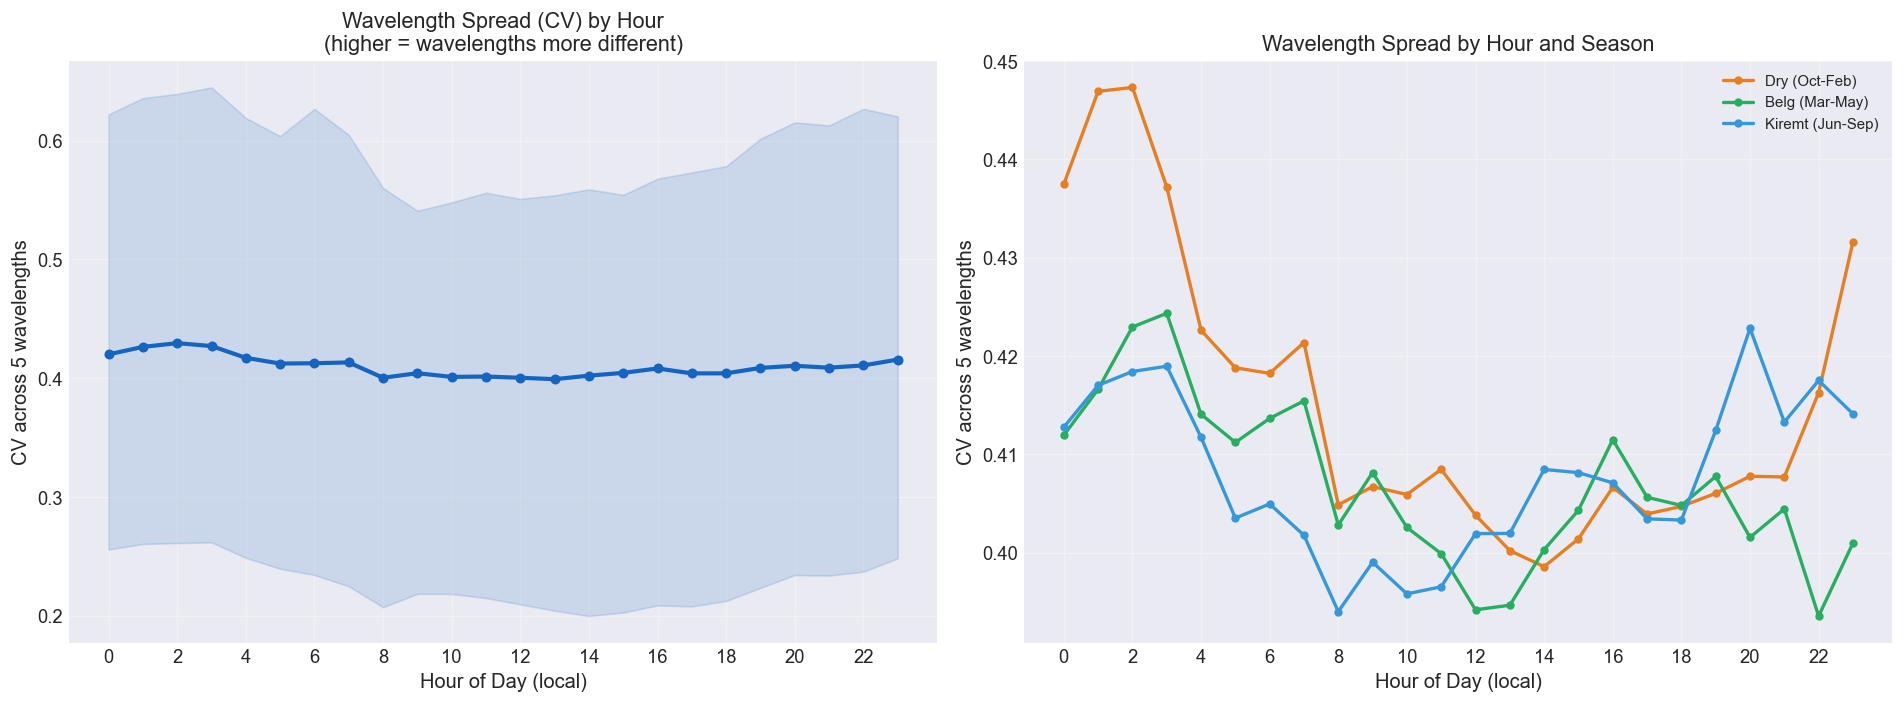

In [7]:
# CV across wavelengths at each minute
bc_matrix = df[list(BC_COLS.values())]
row_mean = bc_matrix.mean(axis=1)
row_std = bc_matrix.std(axis=1)
df['wl_CV'] = (row_std / row_mean).where(row_mean > 0.1)

# Also compute max/min ratio (another spread metric)
df['wl_max_min_ratio'] = bc_matrix.max(axis=1) / bc_matrix.min(axis=1).where(
    bc_matrix.min(axis=1) > 0.1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: CV by hour ---
ax = axes[0]
hourly = df.groupby('Hour')['wl_CV']
med = hourly.median()
q25 = hourly.quantile(0.25)
q75 = hourly.quantile(0.75)

ax.plot(med.index, med.values, 'o-', lw=2.5, ms=5, color='#1565C0')
ax.fill_between(med.index, q25, q75, alpha=0.15, color='#1565C0')
ax.set_xlabel('Hour of Day (local)')
ax.set_ylabel('CV across 5 wavelengths')
ax.set_title('Wavelength Spread (CV) by Hour\n(higher = wavelengths more different)')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)

# --- Right: CV by hour and season ---
ax = axes[1]
for season, color in SEASON_COLORS.items():
    sdata = df[df['Season'] == season]
    hourly = sdata.groupby('Hour')['wl_CV']
    med = hourly.median()
    ax.plot(med.index, med.values, 'o-', lw=2, ms=4, color=color, label=season)

ax.set_xlabel('Hour of Day (local)')
ax.set_ylabel('CV across 5 wavelengths')
ax.set_title('Wavelength Spread by Hour and Season')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/diurnal_wavelength_spread.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Seasonal Diurnal Multi-Wavelength Patterns

Full multi-wavelength overlay for each Ethiopian season, to see if the wavelength
divergence pattern varies with season (e.g., more divergence during dry season when
biomass burning is prevalent).

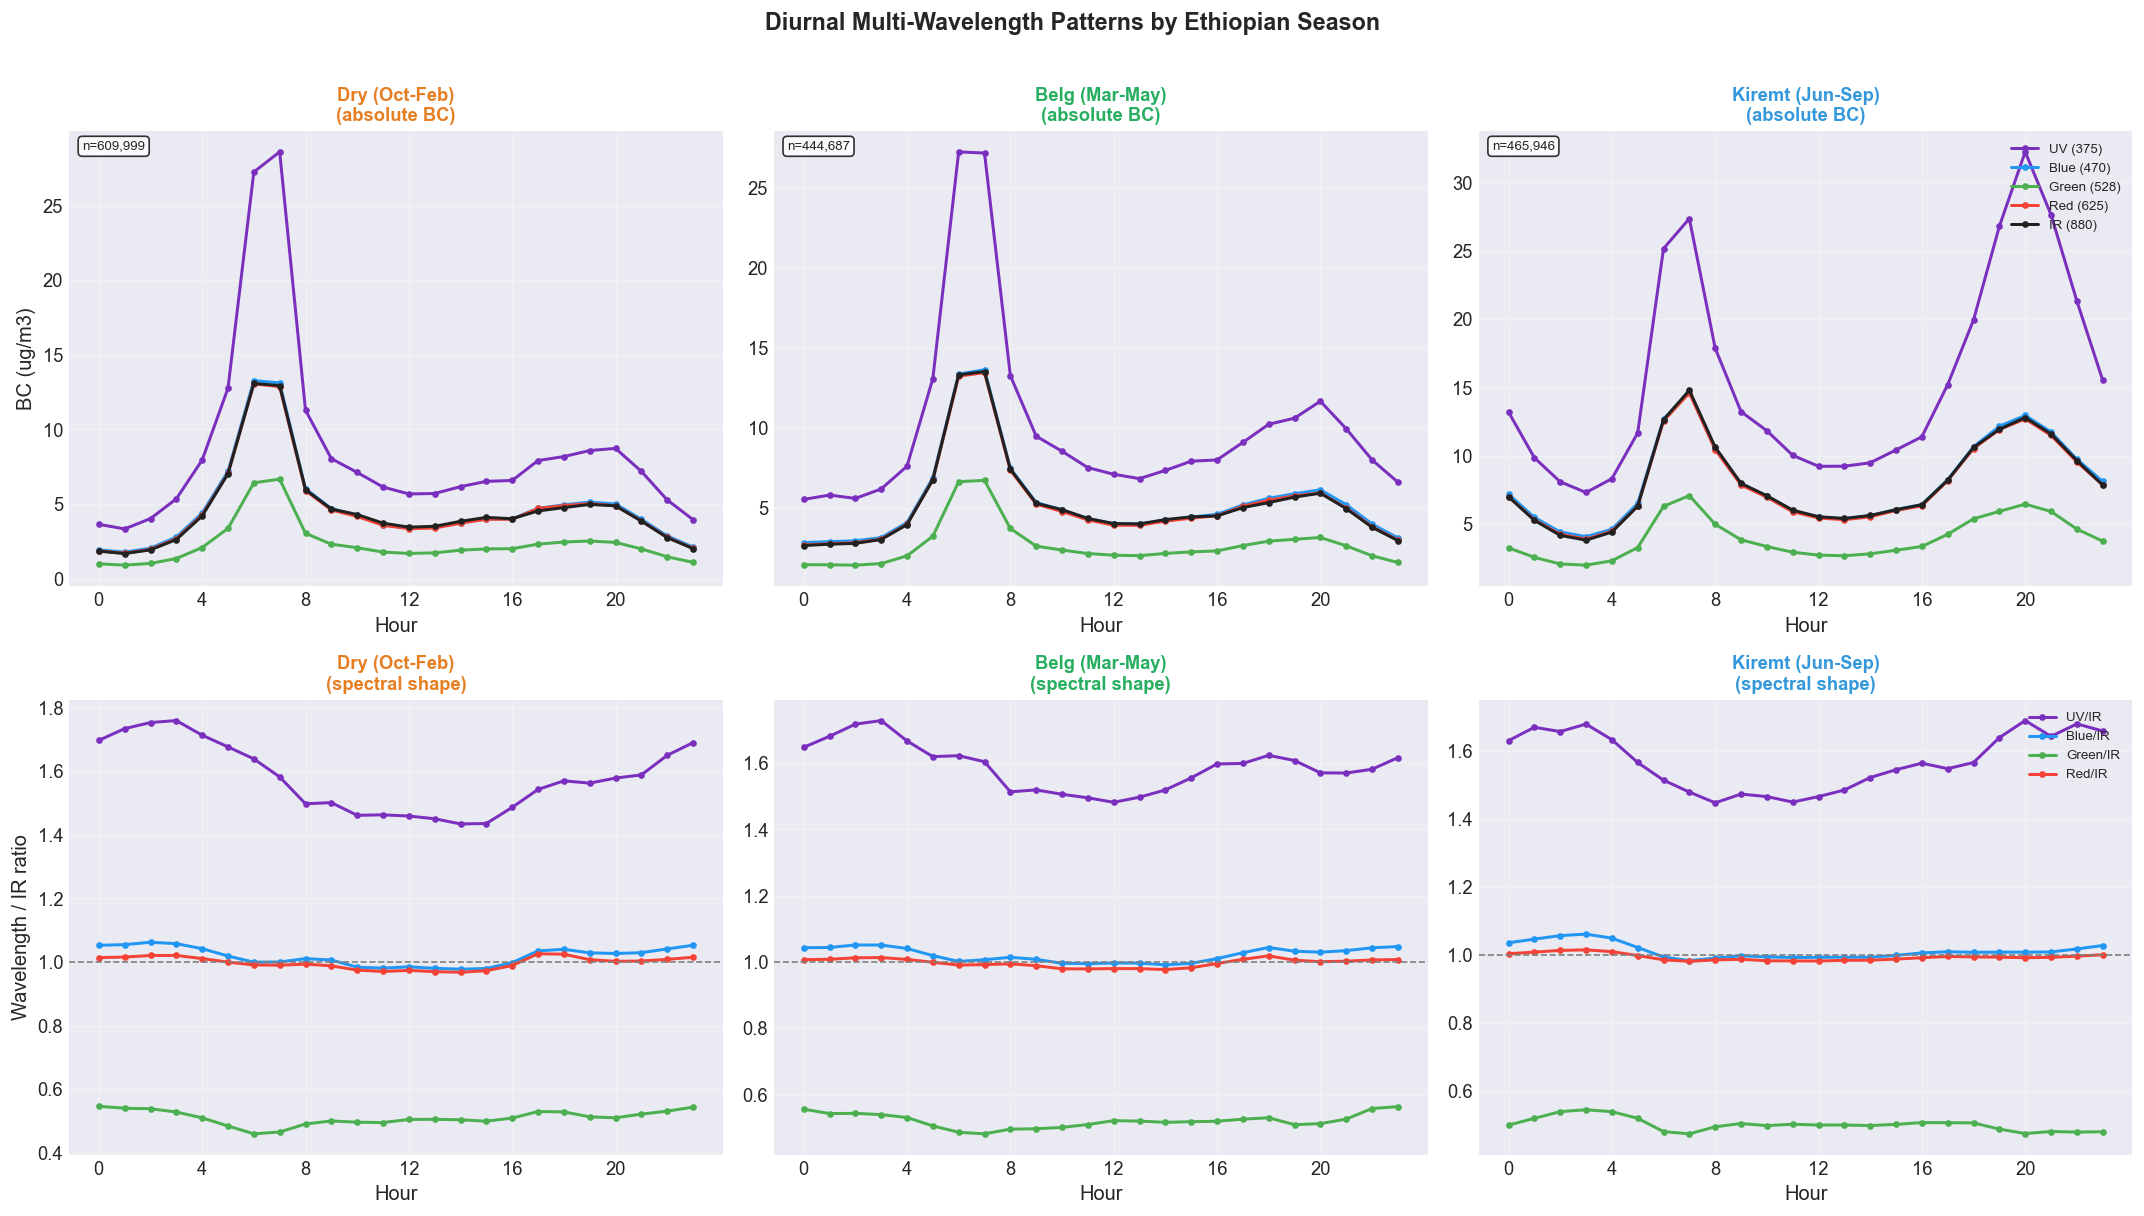

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

season_list = list(SEASONS.keys())

# Top row: absolute concentrations by season
for idx, season in enumerate(season_list):
    ax = axes[0, idx]
    sdata = df[df['Season'] == season]
    for name, info in WAVELENGTHS.items():
        col = BC_COLS[name]
        med = sdata.groupby('Hour')[col].median()
        ax.plot(med.index, med.values, 'o-', ms=3, lw=1.8,
                color=info['color'], label=f"{name} ({info['nm']})")
    ax.set_title(f'{season}', fontsize=12, fontweight='bold',
                 color=SEASON_COLORS[season])
    ax.set_xlabel('Hour')
    if idx == 0:
        ax.set_ylabel('BC (ug/m3)')
    ax.set_xticks(range(0, 24, 4))
    ax.grid(True, alpha=0.3)
    if idx == 2:
        ax.legend(fontsize=8, loc='upper right')
    n = sdata[BC_COLS['IR']].notna().sum()
    ax.text(0.02, 0.98, f'n={n:,}', transform=ax.transAxes, fontsize=8,
            va='top', ha='left', bbox=dict(boxstyle='round', fc='w', alpha=0.8))

# Bottom row: UV/IR ratio by season (spectral shape)
for idx, season in enumerate(season_list):
    ax = axes[1, idx]
    sdata = df[df['Season'] == season]
    for name in ['UV', 'Blue', 'Green', 'Red']:
        rcol = ratio_cols[name]
        med = sdata.groupby('Hour')[rcol].median()
        info = WAVELENGTHS[name]
        ax.plot(med.index, med.values, 'o-', ms=3, lw=1.8,
                color=info['color'], label=f"{name}/IR")
    ax.axhline(1.0, color='gray', ls='--', lw=1)
    ax.set_xlabel('Hour')
    if idx == 0:
        ax.set_ylabel('Wavelength / IR ratio')
    ax.set_xticks(range(0, 24, 4))
    ax.grid(True, alpha=0.3)
    if idx == 2:
        ax.legend(fontsize=8, loc='upper right')

axes[0, 0].set_title(f'{season_list[0]}\n(absolute BC)', fontsize=11,
                       fontweight='bold', color=SEASON_COLORS[season_list[0]])
axes[1, 0].set_title(f'{season_list[0]}\n(spectral shape)', fontsize=11,
                       fontweight='bold', color=SEASON_COLORS[season_list[0]])
for idx in [1, 2]:
    axes[0, idx].set_title(f'{season_list[idx]}\n(absolute BC)', fontsize=11,
                           fontweight='bold', color=SEASON_COLORS[season_list[idx]])
    axes[1, idx].set_title(f'{season_list[idx]}\n(spectral shape)', fontsize=11,
                           fontweight='bold', color=SEASON_COLORS[season_list[idx]])

plt.suptitle('Diurnal Multi-Wavelength Patterns by Ethiopian Season', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/diurnal_seasonal_wavelengths.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Representative Individual Days

Show a few individual days with the full 24-hour multi-wavelength time series at 1-minute
resolution, similar to Sean's Queens College plot. Pick days from different seasons and
with varying levels of wavelength divergence.

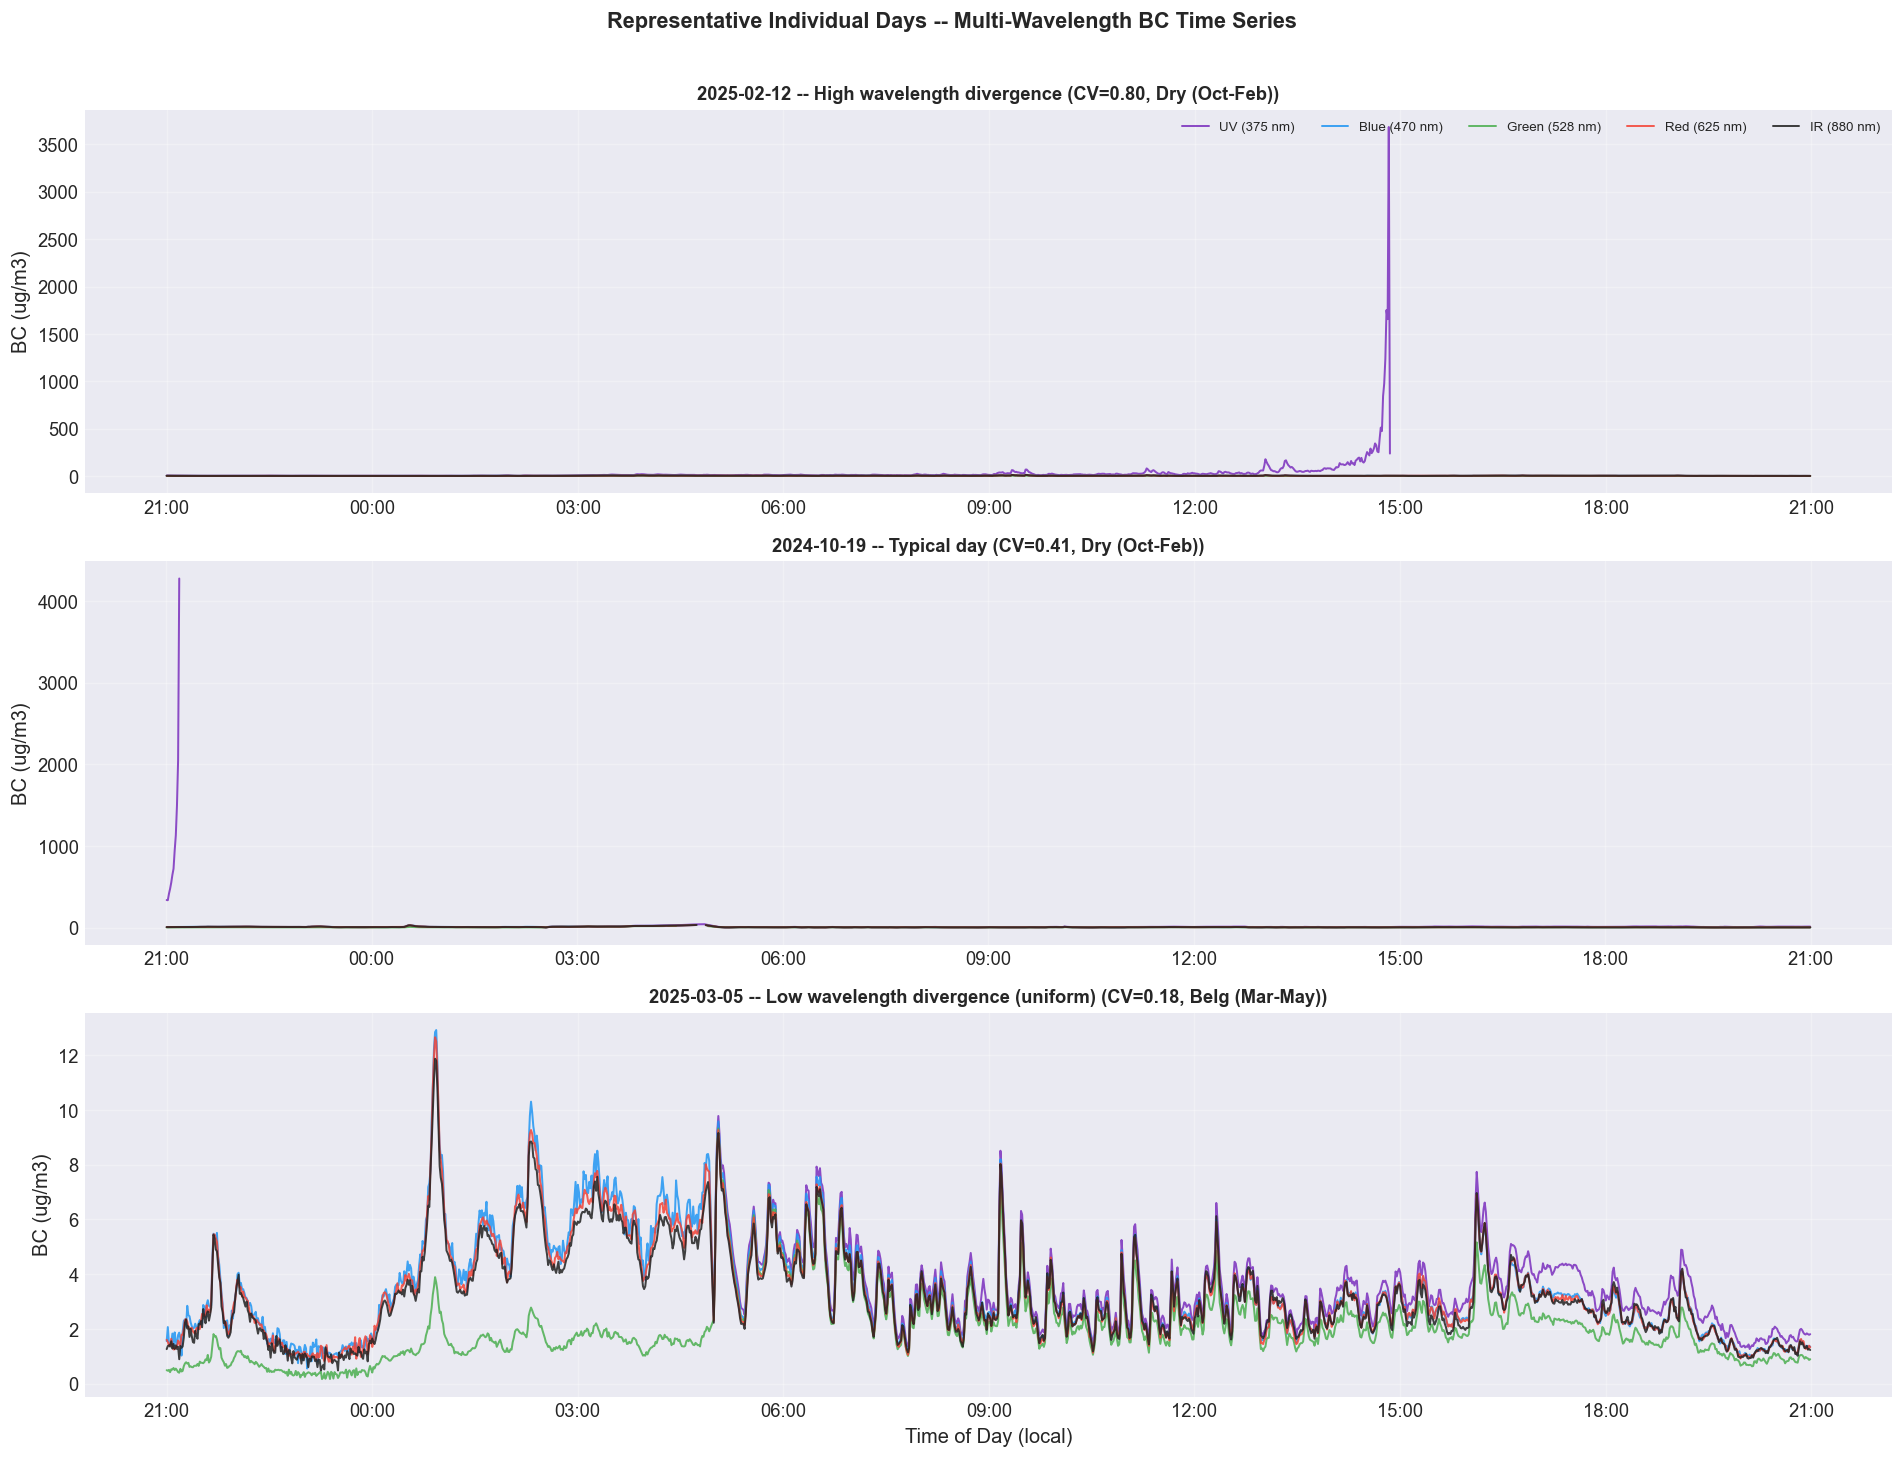

High divergence day: 2025-02-12  (CV = 0.80)
Typical day:         2024-10-19  (CV = 0.41)
Low divergence day:  2025-03-05  (CV = 0.18)


In [9]:
# Find representative days: pick ones with high, medium, and low daily CV spread
daily_cv = df.groupby('Date')['wl_CV'].median().dropna()
daily_count = df.groupby('Date')[BC_COLS['IR']].count()

# Only consider days with >= 1200 valid minutes (83% completeness)
good_days = daily_count[daily_count >= 1200].index
daily_cv = daily_cv.loc[daily_cv.index.isin(good_days)]

# Pick representative days
high_cv_day = daily_cv.nlargest(20).index[5]   # high divergence (skip top outliers)
low_cv_day = daily_cv.nsmallest(20).index[5]    # low divergence
med_cv_day = daily_cv.iloc[(daily_cv - daily_cv.median()).abs().argsort()[:1]].index[0]

example_days = [
    (high_cv_day, 'High wavelength divergence'),
    (med_cv_day, 'Typical day'),
    (low_cv_day, 'Low wavelength divergence (uniform)'),
]

fig, axes = plt.subplots(len(example_days), 1, figsize=(16, 4 * len(example_days)))

for idx, (day, desc) in enumerate(example_days):
    ax = axes[idx]
    day_data = df[df['Date'] == day]

    for name, info in WAVELENGTHS.items():
        col = BC_SMOOTH_COLS.get(name, BC_COLS[name])
        if col in day_data.columns:
            ax.plot(day_data.index, day_data[col], lw=1.2,
                    color=info['color'], label=f"{name} ({info['nm']} nm)", alpha=0.85)

    season = day_data['Season'].iloc[0] if len(day_data) > 0 else '?'
    ax.set_title(f'{day} -- {desc} (CV={daily_cv[day]:.2f}, {season})',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('BC (ug/m3)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right', ncol=5)
    if idx == len(example_days) - 1:
        ax.set_xlabel('Time of Day (local)')

plt.suptitle('Representative Individual Days -- Multi-Wavelength BC Time Series',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/example_days_wavelengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"High divergence day: {high_cv_day}  (CV = {daily_cv[high_cv_day]:.2f})")
print(f"Typical day:         {med_cv_day}  (CV = {daily_cv[med_cv_day]:.2f})")
print(f"Low divergence day:  {low_cv_day}  (CV = {daily_cv[low_cv_day]:.2f})")

---
## 8. Hour-of-Day Heatmap (Wavelength x Hour)

A heatmap showing the normalized BC (each wavelength normalized to its own daily mean)
across hours, giving a compact view of the diurnal spectral fingerprint.

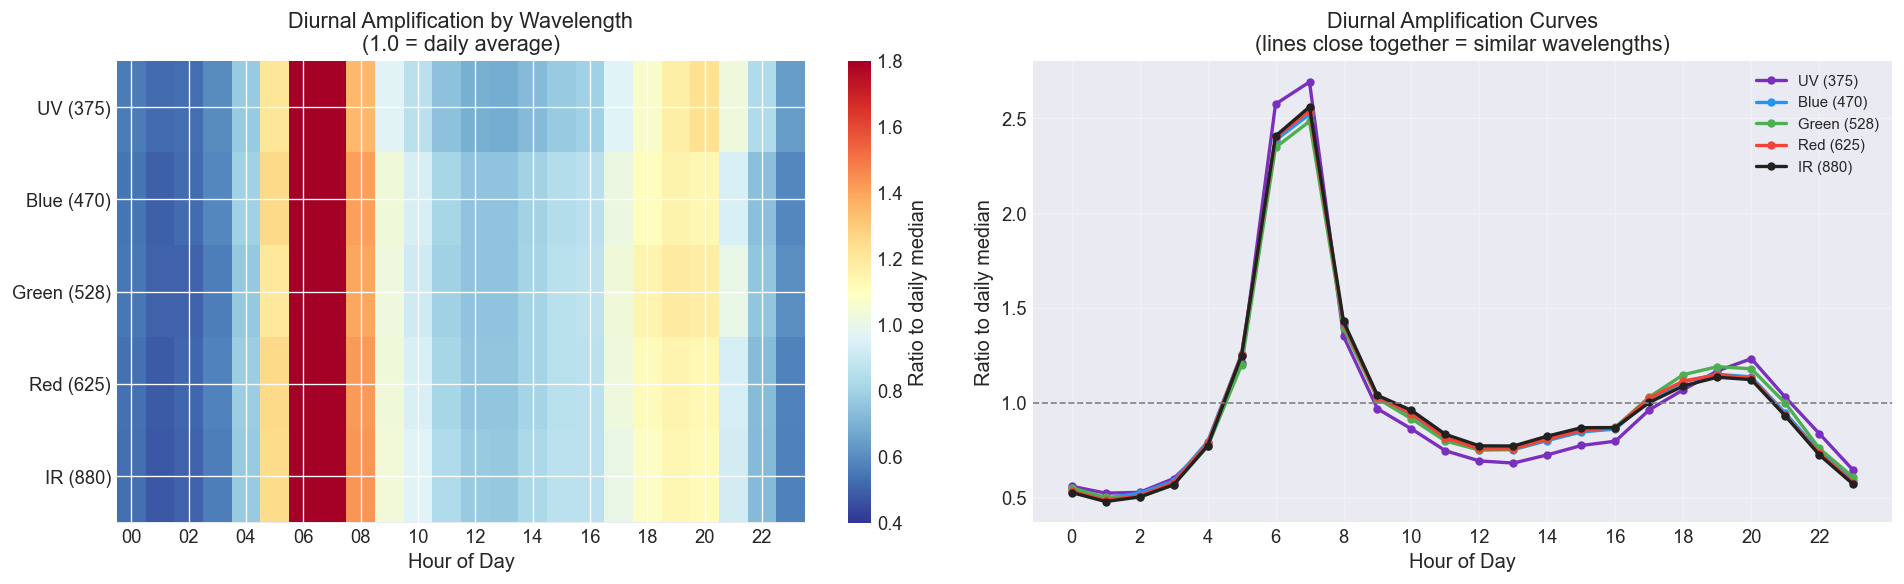

Hours with most wavelength divergence: [6, 7, 20]
Hours with most wavelength convergence: [4, 2, 0]


In [10]:
# Normalized diurnal pattern: for each wavelength, divide hourly median by the daily median
# This shows relative amplification at each hour (1.0 = daily average)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Heatmap ---
ax = axes[0]
wl_names = list(WAVELENGTHS.keys())
heatmap_data = np.zeros((len(wl_names), 24))

for i, name in enumerate(wl_names):
    col = BC_COLS[name]
    hourly_med = df.groupby('Hour')[col].median()
    daily_med = hourly_med.mean()
    heatmap_data[i, :] = hourly_med.values / daily_med if daily_med > 0 else 0

wl_labels = [f"{name} ({WAVELENGTHS[name]['nm']})" for name in wl_names]
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlBu_r', vmin=0.4, vmax=1.8)
ax.set_yticks(range(len(wl_labels)))
ax.set_yticklabels(wl_labels)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}' for h in range(0, 24, 2)])
ax.set_xlabel('Hour of Day')
ax.set_title('Diurnal Amplification by Wavelength\n(1.0 = daily average)')
plt.colorbar(im, ax=ax, label='Ratio to daily median')

# --- Right: Same data as line plot (easier to compare convergence/divergence) ---
ax = axes[1]
for i, name in enumerate(wl_names):
    info = WAVELENGTHS[name]
    ax.plot(range(24), heatmap_data[i, :], 'o-', lw=2, ms=4,
            color=info['color'], label=f"{name} ({info['nm']})")

ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Ratio to daily median')
ax.set_title('Diurnal Amplification Curves\n(lines close together = similar wavelengths)')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/diurnal_heatmap_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify: at which hours are the curves most spread vs most collapsed?
spread_by_hour = np.std(heatmap_data, axis=0)
print(f"Hours with most wavelength divergence: {np.argsort(spread_by_hour)[-3:][::-1].tolist()}")
print(f"Hours with most wavelength convergence: {np.argsort(spread_by_hour)[:3].tolist()}")

---
## 9. Summary Statistics Table

Tabular summary of all diurnal wavelength metrics by time block and season.

In [11]:
# Summary table: key metrics by time block and season
rows = []
for season in list(SEASONS.keys()) + ['All']:
    if season == 'All':
        sdata = df
    else:
        sdata = df[df['Season'] == season]

    for block_label, (h0, h1) in time_blocks.items():
        mask = (sdata['Hour'] >= h0) & (sdata['Hour'] < h1)
        block = sdata[mask]

        row = {
            'Season': season,
            'Time Block': block_label,
            'n_minutes': block[BC_COLS['IR']].notna().sum(),
            'IR_BCc_median': block[BC_COLS['IR']].median(),
            'UV_BCc_median': block[BC_COLS['UV']].median(),
            'UV_IR_ratio_median': block['UV/IR ratio'].median() if 'UV/IR ratio' in block.columns else np.nan,
            'AAE_UV_IR_median': block['AAE_UV_IR'].median(),
            'Delta_C_median': block['Delta_C'].median(),
            'wl_CV_median': block['wl_CV'].median(),
        }
        rows.append(row)

summary = pd.DataFrame(rows)
summary = summary.round(3)

# Save
summary.to_csv(f'{PLOT_DIR}/diurnal_wavelength_summary.csv', index=False)
print(f"Summary saved to {PLOT_DIR}/diurnal_wavelength_summary.csv")

# Display for "All" seasons
display_cols = ['Time Block', 'n_minutes', 'IR_BCc_median', 'UV_IR_ratio_median',
                'AAE_UV_IR_median', 'Delta_C_median', 'wl_CV_median']
print("\n=== Overall (all seasons) ===")
print(summary[summary['Season'] == 'All'][display_cols].to_string(index=False))

print("\n=== By Season ===")
for season in SEASONS.keys():
    print(f"\n--- {season} ---")
    print(summary[summary['Season'] == season][display_cols].to_string(index=False))

Summary saved to output/plots/addis_ababa/diurnal_wavelength/diurnal_wavelength_summary.csv

=== Overall (all seasons) ===
        Time Block  n_minutes  IR_BCc_median  UV_IR_ratio_median  AAE_UV_IR_median  Delta_C_median  wl_CV_median
     00-05 (night)     322157          3.092               1.693             0.618           2.193         0.424
   05-09 (morning)     240055          9.522               1.566             0.526           4.831         0.410
    09-13 (midday)     258650          4.832               1.477             0.457           2.313         0.402
 13-17 (afternoon)     260088          4.503               1.498             0.474           2.126         0.404
   17-21 (evening)     251135          5.866               1.585             0.540           3.612         0.407
21-24 (late night)     188547          4.101               1.629             0.572           3.020         0.412

=== By Season ===

--- Dry (Oct-Feb) ---
        Time Block  n_minutes  IR_BCc_median

---
## Interpretation Guide

**Answering Ann's question** -- "Is the aethalometer data the same all the time in Addis?"

Metrics to look at:
- **UV/IR ratio**: If it stays near 1.0 all day, the wavelengths are "the same" (fossil fuel dominant). If it swings higher at night/morning, biomass burning contributes during those hours.
- **AAE**: Same interpretation. AAE ~1 = uniform/fossil fuel. AAE >1.5 = biomass contribution.
- **Wavelength CV**: Low and flat = "same all the time". If it has diurnal peaks, the source mixture is changing.
- **Delta-C**: Near zero = uniform. Positive peaks = biomass episodes.

**Comparison with Queens College, NY (Sean's data)**:
- NY showed dramatic wavelength divergence 1-5 AM and convergence 5-9 AM, driven by an overnight airmass shift.
- In Addis, the pattern may be driven by different mechanisms: evening/nighttime biomass burning (cooking, heating) vs. daytime traffic emissions.

**Note**: We only have high-resolution data for Addis Ababa. The other sites (Beijing, Delhi, JPL) are only available as daily averages in this repository.